In [1]:
#importing libraries
import ast 
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Ezekiel\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Apr  2 10:40:05 2026).


In [2]:
df['job_skills']= df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_exploded= df.explode('job_skills')

In [9]:
df_exploded_group = df_exploded.groupby(['job_title_short', 'job_skills']).size()

In [20]:
df_exploded_group= df_exploded_group.reset_index(name= 'skill_count')


In [22]:
df_exploded_group= df_exploded_group.sort_values(by= 'skill_count', ascending= False)

df_exploded_group

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [38]:
title= 'Data Analyst'
top_skills= 10

In [39]:
df_filter= df_exploded_group[df_exploded_group['job_title_short']== title].head(top_skills)

df_filter

,job_title_short,job_skills,skill_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


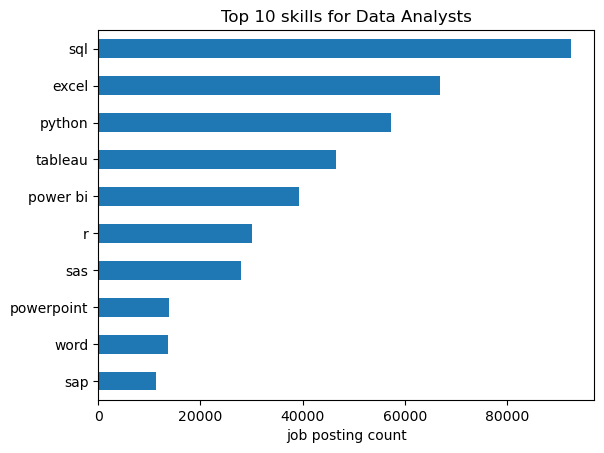

In [44]:
df_filter.plot(kind='barh', x= "job_skills", y='skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} skills for {title}s')
plt.xlabel('job posting count')
plt.ylabel("")
plt.legend().set_visible(False)
plt.show()